## Visualization for the synthetic DE experiment in section 4.1

In [1]:
import torch
import matplotlib.pyplot as plt
from tailnflows.models import flows
from tailnflows.targets.heavy_tailed_nuisance import log_density, generate_data
from tailnflows.plot_utils import plot_contour

/home/vonbalnd/micromamba/envs/py39/lib/python3.9/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


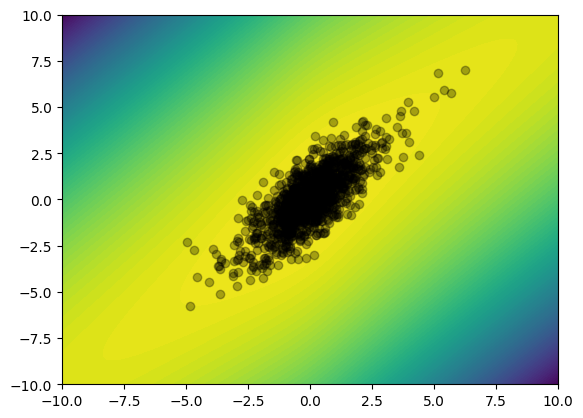

In [2]:
# sense check data + distribution
# for synthetic distribution in section 4.1 in 2 dimensions
target_df = 5.

x_trn = generate_data(1300, 2, target_df)
x_val = generate_data(650, 2, target_df)
x_tst = generate_data(3000, 2, target_df)

fig, ax = plt.subplots(1, 1)
plot_contour(
    ax, 
    lambda x: log_density(x,target_df), 
    x_trn.shape[1], 
    target_x_0=-2,
    target_x_1=-1,
    min=-10,
    max=10,
    num_levels=100
)
ax.scatter(x_trn[:, 0], x_trn[:, 1], alpha=0.3, c='black')
ax.set_xlim((-10.0, 10.0))
ax.set_ylim((-10.0, 10.0))
plt.show()

# contour: true log-density
# scatter: training samples

### Model: TTF_m

normal $N(0,I)$ -> auto reg RQS (rational quadratic spline) layer -> auto reg affine layer-> tail marginal

In [3]:
from tailnflows.train.data_fit import train
from functools import partial

dim = 2
tails = torch.tensor([1 / target_df, 1 / target_df])

# flows.build_ttf_m puts the TTF transformation at the end of the NF flow specified in its arguments (see markdown above)
flow = flows.build_ttf_m(
    dim,
    'density_estimation',
    base_transformation_init=partial(
        flows.base_nsf_transform,
        affine_autoreg_layer=True,
    ),
    model_kwargs=dict(
        pos_tail_init=tails,
        neg_tail_init=tails,
        fix_tails=True,
    ), # pyright: ignore[reportArgumentType]
)

fit_data = train(flow, x_trn, x_val, x_tst, lr=5e-3, num_steps=300, batch_size=100, label='')
# fit_data = loss results and other training data

/home/vonbalnd/MApaper/tailnflows/tailnflows/models/flows.py:517: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_tail_init=torch.tensor(pos_tail_init),
/home/vonbalnd/MApaper/tailnflows/tailnflows/models/flows.py:518: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  neg_tail_init=torch.tensor(neg_tail_init),
100%|██████████| 300/300 [00:03<00:00, 92.37it/s, loss=3.29 (3.07) : *3.072 @ 280] 


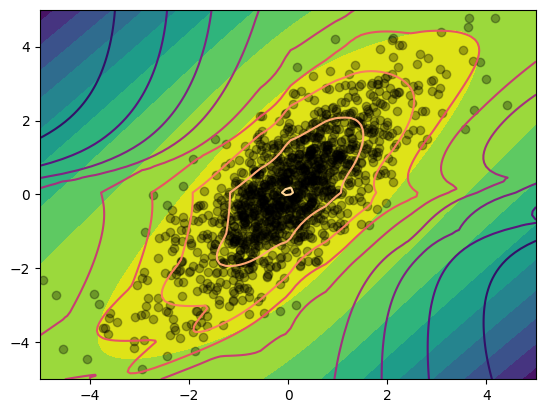

In [4]:
fig, ax = plt.subplots(1, 1)
plot_contour(ax, lambda x: log_density(x,target_df), x_trn.shape[1], target_x_0=-2, target_x_1=-1)
plot_contour(ax, lambda x: flow.log_prob(x).detach(), x_trn.shape[1], target_x_0=-2, target_x_1=-1, contour_type='line')
ax.scatter(x_trn[:, 0], x_trn[:, 1], alpha=0.3, c='black')
ax.set_xlim((-5.0, 5.0))
ax.set_ylim((-5.0, 5.0))
plt.show()

# contour background: true log-density
# contour line: log-density learned by the flow
# scatter: training samples

### Model: MTAF

In [9]:
dim = 2
# dfs = torch.tensor([target_df, target_df])
# second marginal is light-tailed, therefore we should give df=0 for the second marginal I think!
dfs = torch.tensor([target_df, 0])

flow = flows.build_mtaf(
    dim,
    'density_estimation',
    base_transformation_init=partial(
        flows.base_nsf_transform,
        affine_autoreg_layer=True,
    ),
    model_kwargs=dict(
        tail_init=dfs,
        fix_tails=True,
    ), # pyright: ignore[reportArgumentType]
)

fit_data = train(flow, x_trn, x_val, x_tst, lr=1e-3, num_steps=300, batch_size=100, label='')

100%|██████████| 300/300 [00:03<00:00, 84.23it/s, loss=3.02 (3.20) : *3.212 @ 299]


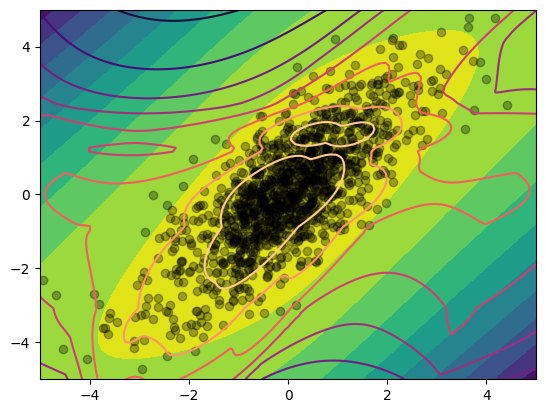

In [10]:
fig, ax = plt.subplots(1, 1)
plot_contour(ax, lambda x: log_density(x,target_df), x_trn.shape[1], target_x_0=-2, target_x_1=-1)
plot_contour(ax, lambda x: flow.log_prob(x).detach(), x_trn.shape[1], target_x_0=-2, target_x_1=-1, contour_type='line')
ax.scatter(x_trn[:, -2], x_trn[:, -1], alpha=0.3, c='black')
ax.set_xlim((-5.0, 5.0))
ax.set_ylim((-5.0, 5.0))
plt.show()

### Model: COMET

In [7]:
dim = 2

flow = flows.build_comet(
    dim,
    'density_estimation',
    base_transformation_init=partial(
        flows.base_nsf_transform,
        affine_autoreg_layer=True,
    ),
    model_kwargs=dict(
        data=x_trn,
        fix_tails=True,
        tail_init=[target_df, target_df]
    ), # pyright: ignore[reportArgumentType]
)

fit_data = train(flow, x_trn, x_val, x_tst, lr=1e-3, num_steps=300, batch_size=100, label='')

100%|██████████| 300/300 [00:35<00:00,  8.34it/s, loss=3.10 (3.07) : *3.096 @ 299]


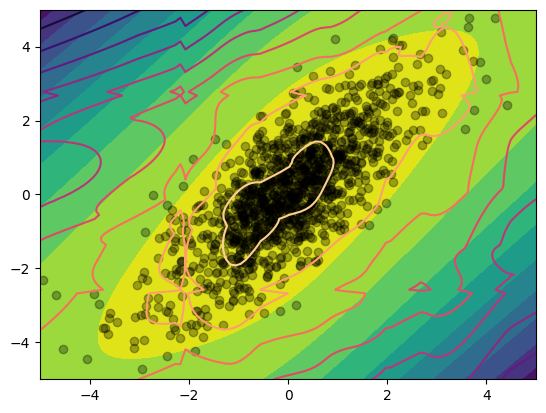

In [8]:
fig, ax = plt.subplots(1, 1)
plot_contour(ax, lambda x: log_density(x,target_df), x_trn.shape[1], target_x_0=0, target_x_1=1)
plot_contour(ax, lambda x: flow.log_prob(x).detach(), x_trn.shape[1], target_x_0=0, target_x_1=1,contour_type='line')
ax.scatter(x_trn[:, -2], x_trn[:, -1], alpha=0.3, c='black')
ax.set_xlim((-5.0, 5.0))
ax.set_ylim((-5.0, 5.0))
plt.show()